In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [3]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")

In [4]:
trans_df = pd.read_csv("../../Data/transactions_260325.csv")

In [5]:
# 오퍼+결제 만들기
# 1. 오퍼 완료(completed) 기록만  골라내기
completed_df = merge_df[merge_df['event'] == 'completed']

# 2. 결제(transaction) 기록에서 병합에 쓸 '고객', '시간' 그리고 우리가 찾던 '매출(amount)'만 가져오기
transaction_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# 3. Merge 'person'과 'time'이 일치하는 데이터끼리 붙여주기
offer_linked_df = pd.merge(completed_df, transaction_df, on=['person', 'time'], how='inner')

# 상위 3개 확인해보기
display(offer_linked_df[['person', 'time', 'offer_label', 'amount_y']].head(3))

,person,time,offer_label,amount_y
0,0009655768c64bdeb2e877511632db8f,576,discount_4,10.27
1,0009655768c64bdeb2e877511632db8f,414,bogo_4,8.57
2,0009655768c64bdeb2e877511632db8f,528,discount_3,14.11


In [6]:
# 일반 결제 매출 구하기
# 1. 전체 결제(transaction) 데이터 준비
transaction_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# 2. 아까 구한 '오퍼 연계 결제' 데이터에서 기준이 되는 고객과 시간만 가져오기 (중복 제거)
linked_keys = offer_linked_df[['person', 'time']].drop_duplicates()

# 3. 전체 결제에 오퍼 연계 결제 정보를 Left 조인으로 붙이되, indicator=True를 써서 출처 표시하기
regular_transaction_df = pd.merge(transaction_df, linked_keys, on=['person', 'time'], how='left', indicator=True)

# 4. '_merge' 컬럼이 'left_only'인 것(전체 결제에는 있는데 오퍼 결제에는 없는 것)만 골라내기
regular_transaction_df = regular_transaction_df[regular_transaction_df['_merge'] == 'left_only']

# 5. 보기 싫은 '_merge' 컬럼은 지워주기
regular_transaction_df = regular_transaction_df.drop(columns=['_merge'])

# 상위 3개 확인해보기
display(regular_transaction_df.head(3))

,person,time,amount
0,0009655768c64bdeb2e877511632db8f,228,22.16
3,0009655768c64bdeb2e877511632db8f,552,13.56
5,0009655768c64bdeb2e877511632db8f,660,12.36


In [7]:
import pandas as pd
import ast

# 1. '다중오퍼' 결제 정보 미리 준비 (txn_offer_type -> tx_offer_type 으로 수정)
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 2. 다중오퍼로 끝난 경로(Key) 추출
completions_all = merge_df[merge_df['event'] == 'completed']
multi_path_keys = pd.merge(completions_all, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path_keys[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# 3. 분석 대상 이벤트 추출 (인포메이셔널 제외)
funnel_df = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)].copy()

# 4. 다중오퍼 경로 태깅 및 라벨링
funnel_df = pd.merge(funnel_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')
funnel_df['final_label'] = funnel_df.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

# 5. 단계별 카운트 계산 (Received & Completed)
received_counts = funnel_df[funnel_df['event'] == 'received'].groupby('final_label').size()
completed_counts = funnel_df[funnel_df['event'] == 'completed'].groupby('final_label').size()

# 6. 완료율 데이터프레임 생성
funnel_summary = pd.DataFrame({
    '총발송수': received_counts,
    '총완료수': completed_counts
}).reset_index()

# 전체 완료율 (%) 계산
funnel_summary['전체완료율'] = (funnel_summary['총완료수'] / funnel_summary['총발송수']) * 100

# 완료율 높은 순으로 정렬
funnel_summary = funnel_summary.sort_values(by='전체완료율', ascending=False).reset_index(drop=True)

# 결과 확인
display(funnel_summary)

,final_label,총발송수,총완료수,전체완료율
0,다중오퍼,2691,2879,106.986250
1,discount_3,7258,4897,67.470378
2,discount_2,7351,4791,65.174806
3,bogo_4,7268,3928,54.045129
4,bogo_3,7260,3860,53.168044
5,discount_4,7323,3637,49.665438
6,bogo_1,7322,3277,44.755531
7,bogo_2,7320,3006,41.065574
8,discount_1,7249,2907,40.102083


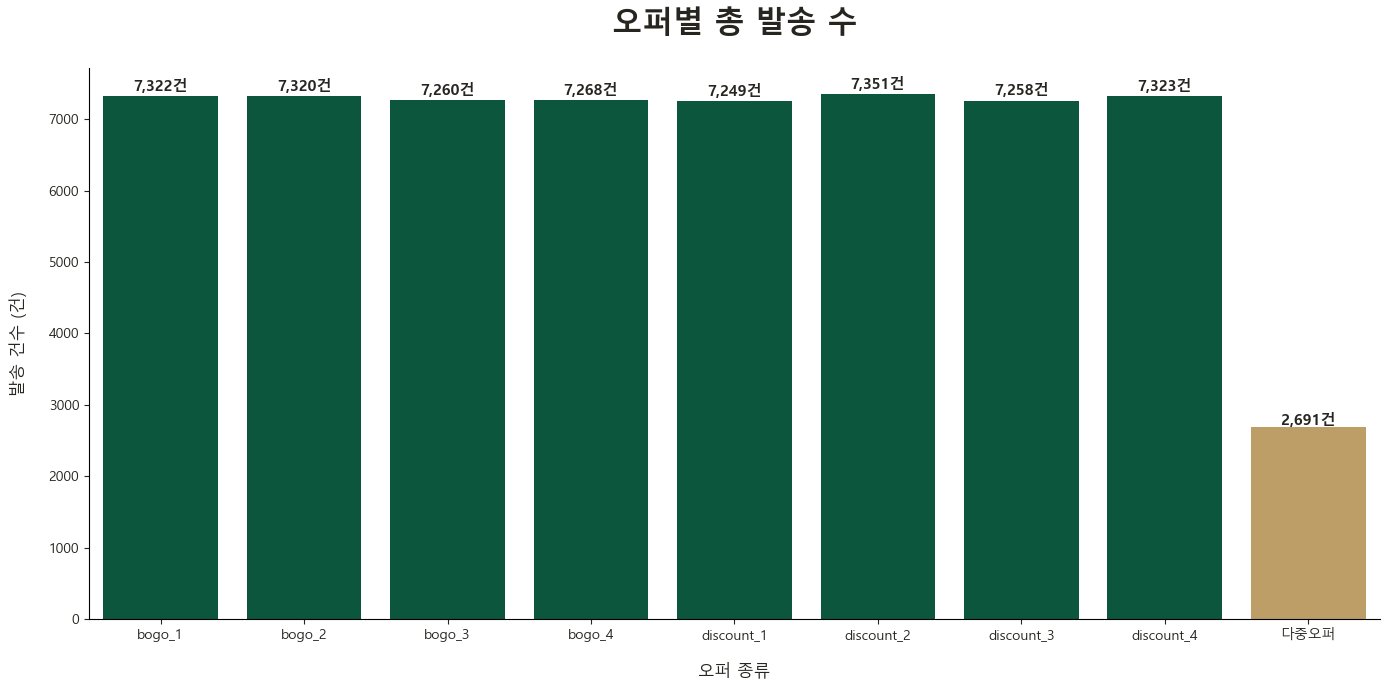

In [8]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 데이터 계산 파트 (sent_counts 만들기)
# ==========================================

# 1) '다중오퍼' 결제 정보 추출 (tx_offer_type 오타 수정 반영)
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 2) 다중오퍼로 끝난 경로(Key) 추출
completions_all = merge_df[merge_df['event'] == 'completed']
multi_path_keys = pd.merge(completions_all, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path_keys[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# 3) 발송(received) 데이터만 추출 (인포메이셔널 제외)
received_df = merge_df[(merge_df['event'] == 'received') & 
                       (~merge_df['offer_label'].str.contains('informational', na=False))].copy()

# 4) 다중오퍼 경로 태깅 및 라벨링
received_tagged = pd.merge(received_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')
received_tagged['final_label'] = received_tagged.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

# 5) 드디어 sent_counts 생성! (총 발송 수 집계)
sent_counts = received_tagged.groupby('final_label').size().reset_index(name='총발송수')

# 9종 순서 예쁘게 고정
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
sent_counts['final_label'] = pd.Categorical(sent_counts['final_label'], categories=order, ordered=True)
sent_counts = sent_counts.sort_values('final_label')


# ==========================================
# 2. 시각화 파트 (그래프 그리기)
# ==========================================

SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# 색상 배정 (다중오퍼는 골드, 나머지는 그린)
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in sent_counts['final_label']]

# 막대그래프 
ax = sns.barplot(data=sent_counts, x='final_label', y='총발송수', palette=colors)

plt.title('오퍼별 총 발송 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('발송 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 건수 표시 (천 단위 콤마)
for i, v in enumerate(sent_counts['총발송수']):
    ax.text(i, v + (v * 0.01), f"{v:,}건", ha='center', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

오퍼 발송 수는 모두 7000건대에서 비슷함. 유의미한 차이 없음


In [9]:
# 2. 다중 오퍼(multi)로 완료된 결제 정보 추출
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 3. 완료(completed) 이벤트 중 다중 오퍼 결제에 해당하는 경로 식별
completions = merge_df[merge_df['event'] == 'completed']
multi_path_keys = pd.merge(completions, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path_keys[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# 4. 열람(viewed) 이벤트 필터링 및 인포메이셔널 오퍼 제외
viewed_events = merge_df[(merge_df['event'] == 'viewed') & 
                         (~merge_df['offer_label'].str.contains('informational', na=False))].copy()

# 5. 열람 데이터와 다중 오퍼 경로 정보 결합
viewed_counts_tagged = pd.merge(viewed_events, multi_path_keys, 
                                on=['person', 'offer_id', 'receive_seq'], how='left')

# 6. 최종 라벨 결정 (다중 오퍼 경로 여부에 따라 분류)
viewed_counts_tagged['final_label'] = viewed_counts_tagged.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

# 7. 오퍼별 총 열람 수 계산
viewed_counts = viewed_counts_tagged.groupby('final_label').size().reset_index(name='총열람수')

# 열람 수 기준 내림차순 정렬
viewed_counts = viewed_counts.sort_values(by='총열람수', ascending=False).reset_index(drop=True)

# 결과 확인
display(viewed_counts)

,final_label,총열람수
0,discount_2,7064
1,bogo_2,7038
2,discount_3,7015
3,bogo_4,6975
4,bogo_1,6439
5,bogo_3,3950
6,discount_4,3944
7,discount_1,2512
8,다중오퍼,1957


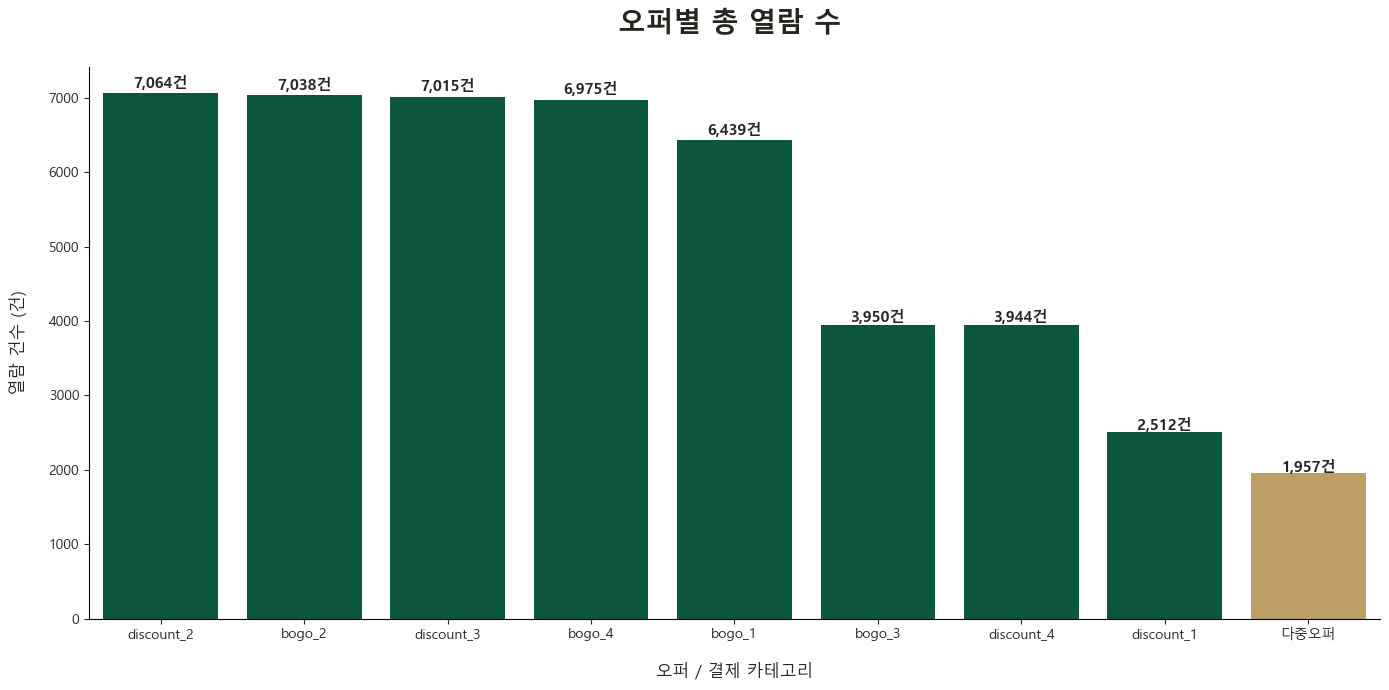

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러 설정
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

# 한글 폰트 설정
plt.rcParams.update({
    'font.family': 'Malgun Gothic', # Windows: 'Malgun Gothic', Mac: 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
})

plt.figure(figsize=(14, 7))

# 색상 배정 (다중오퍼는 골드, 나머지는 그린)
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in viewed_counts['final_label']]

# 막대그래프 그리기
ax = sns.barplot(data=viewed_counts, x='final_label', y='총열람수', palette=colors)

plt.title('오퍼별 총 열람 수 ', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('오퍼 / 결제 카테고리', fontsize=12, labelpad=15)
plt.ylabel('열람 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 건수 표시
for i, v in enumerate(viewed_counts['총열람수']):
    ax.text(i, v + (v * 0.01), f"{v:,}건", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

discoount 2,3 과 1,4 / bogo 2,4,1 과 3의 열람 수 차이가 유의미한 수준임. 같은 종류의 오퍼라도 고객들의 열람을 유도하는 다른 요인이 존재할 것으로 추정됨.

In [11]:
# 2. '다중오퍼(multi)'로 완료된 결제 정보 추출 (trans_df 활용)
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 3. 완료(completed) 이벤트 필터링 및 인포메이셔널 오퍼 제외
completed_events = merge_df[(merge_df['event'] == 'completed') & 
                             (~merge_df['offer_label'].str.contains('informational', na=False))].copy()

# 4. 완료 데이터와 다중오퍼 결제 정보 결합
# 한 결제에 여러 오퍼가 포함된 경우(multi), 해당 완료 건들에 모두 '다중오퍼' 태그를 붙입니다.
completed_tagged = pd.merge(completed_events, multi_txn_info, 
                            on=['person', 'time'], how='left')

# 5. 최종 라벨 결정: 다중오퍼 결제면 '다중오퍼', 아니면 원래 'offer_label'
completed_tagged['final_label'] = completed_tagged.apply(
    lambda x: '다중오퍼' if x['is_multi_txn'] == True else x['offer_label'], axis=1
)

# 6. 오퍼별 총 완료 수 계산
completed_counts = completed_tagged.groupby('final_label').size().reset_index(name='총완료수')

# 완료 수 기준으로 내림차순 정렬
completed_counts = completed_counts.sort_values(by='총완료수', ascending=False).reset_index(drop=True)

# 결과 확인
print(" 오퍼별 총 완료 수 ")
display(completed_counts)

 오퍼별 총 완료 수 


,final_label,총완료수
0,discount_3,4903
1,discount_2,4797
2,bogo_4,3932
3,bogo_3,3867
4,discount_4,3639
5,bogo_1,3283
6,bogo_2,3010
7,discount_1,2914
8,다중오퍼,2837


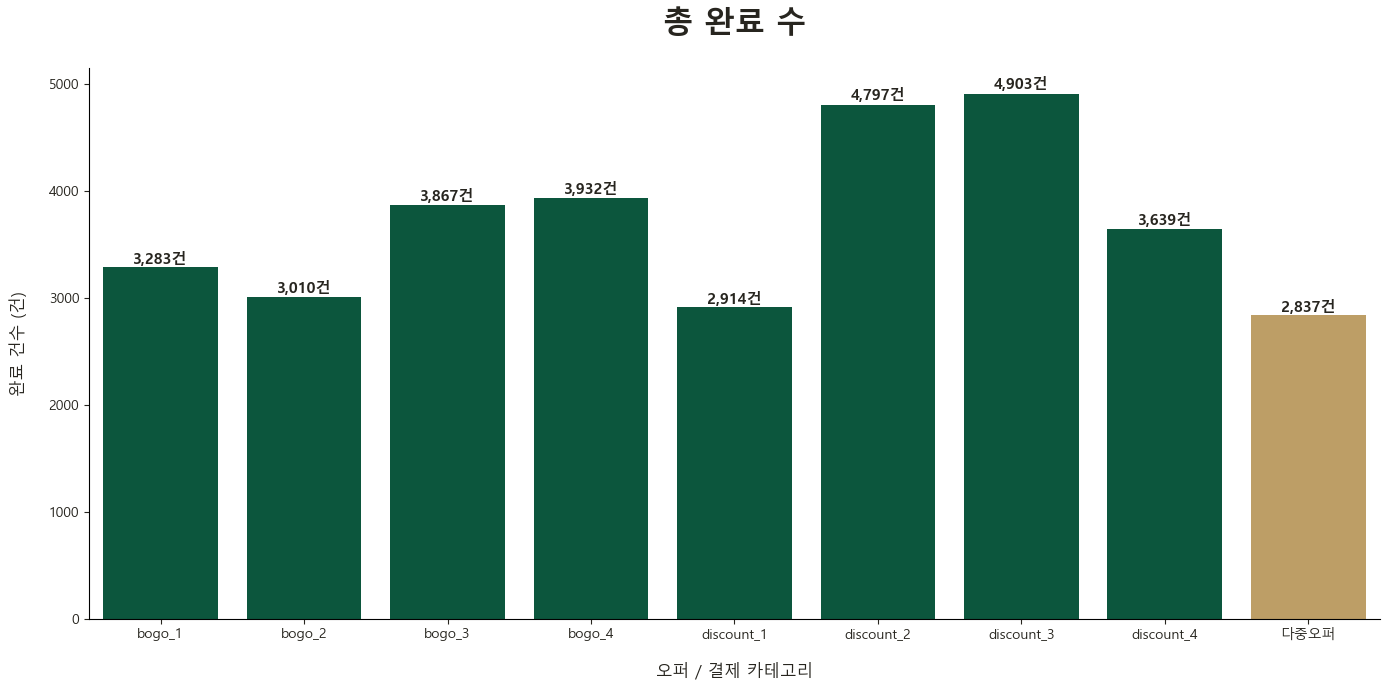

In [12]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# 1. '다중오퍼' 결제 정보 매칭용 데이터 준비
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 2. 완료(completed) 이벤트만 추출 (인포메이셔널 제외)
completed_events = merge_df[(merge_df['event'] == 'completed') & 
                             (~merge_df['offer_label'].str.contains('informational', na=False))].copy()

# 3. 다중오퍼 정보와 결합 (누가 '다중오퍼'로 깼는지 확인)
completed_tagged = pd.merge(completed_events, multi_txn_info, on=['person', 'time'], how='left')

# 4. 최종 라벨 결정 (다중오퍼면 '다중오퍼', 아니면 원래 이름)
completed_tagged['final_label'] = completed_tagged.apply(
    lambda x: '다중오퍼' if x['is_multi_txn'] == True else x['offer_label'], axis=1
)

# 5. 오퍼별 총 완료 수 계산 (reset_index()로 'final_label'을 정식 컬럼으로 만듦)
completed_counts = completed_tagged.groupby('final_label').size().reset_index(name='총완료수')

# 6. 시각화 (제목: 총 완료 수)
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

# 한글 폰트 설정
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# 9종 순서 고정
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
completed_counts['final_label'] = pd.Categorical(completed_counts['final_label'], categories=order, ordered=True)
completed_counts = completed_counts.sort_values('final_label')

# 다중오퍼는 골드, 나머지는 그린
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in completed_counts['final_label']]

ax = sns.barplot(data=completed_counts, x='final_label', y='총완료수', palette=colors)

plt.title('총 완료 수', fontsize=22, fontweight='bold', pad=25) 

plt.xlabel('오퍼 / 결제 카테고리', fontsize=12, labelpad=15)
plt.ylabel('완료 건수 (건)', fontsize=12, labelpad=15)

# 막대 위에 건수 표시
for i, v in enumerate(completed_counts['총완료수']):
    ax.text(i, v + (v * 0.01), f"{v:,}건", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

discount 2,3 이 다른 오퍼들보다 완료 수가 유의미하게 높음. 이를 통해 고객들은 즉각적인 '할인형' 오퍼에 가장 민감하게 반응함을 알 수 있음.

In [13]:
import pandas as pd
import ast

# 1. '다중오퍼' 결제 정보 미리 준비 (정합성 유지)
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 2. 다중오퍼로 끝난 경로(Key) 추출
completions_all = merge_df[merge_df['event'] == 'completed']
multi_path_keys = pd.merge(completions_all, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path_keys[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# 3. 분석 대상 이벤트 추출 (인포메이셔널 제외)
funnel_df = merge_df[~merge_df['offer_label'].str.contains('informational', na=False)].copy()

# 4. 다중오퍼 경로 태깅 및 라벨링
funnel_df = pd.merge(funnel_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')
funnel_df['final_label'] = funnel_df.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

# 5. 단계별 카운트 계산 (Received & Completed)
received_counts = funnel_df[funnel_df['event'] == 'received'].groupby('final_label').size()
completed_counts = funnel_df[funnel_df['event'] == 'completed'].groupby('final_label').size()

# 6. 완료율 데이터프레임 생성
funnel_summary = pd.DataFrame({
    '총발송수': received_counts,
    '총완료수': completed_counts
}).reset_index()

# 전체 완료율 (%) 계산
funnel_summary['전체완료율'] = (funnel_summary['총완료수'] / funnel_summary['총발송수']) * 100

# 완료율 높은 순으로 정렬
funnel_summary = funnel_summary.sort_values(by='전체완료율', ascending=False).reset_index(drop=True)

# 결과 확인
display(funnel_summary)

,final_label,총발송수,총완료수,전체완료율
0,다중오퍼,2691,2879,106.986250
1,discount_3,7258,4897,67.470378
2,discount_2,7351,4791,65.174806
3,bogo_4,7268,3928,54.045129
4,bogo_3,7260,3860,53.168044
5,discount_4,7323,3637,49.665438
6,bogo_1,7322,3277,44.755531
7,bogo_2,7320,3006,41.065574
8,discount_1,7249,2907,40.102083


In [14]:
# [진단 1] 다중오퍼 카테고리에 중복된 완료 데이터가 있는지 확인
multi_completed = funnel_df[(funnel_df['event'] == 'completed') & (funnel_df['final_label'] == '다중오퍼')]
is_duplicate = multi_completed.duplicated(subset=['person', 'offer_id', 'receive_seq', 'time']).sum()

print(f"1. 다중오퍼 완료 건 중 완전 중복 데이터 수: {is_duplicate}건")

# [진단 2] 완료는 됐는데, 정작 '받은 기록(received)'이 없는 경로 찾기
multi_received = funnel_df[(funnel_df['event'] == 'received') & (funnel_df['final_label'] == '다중오퍼')]

# 완료된 경로의 키값만 추출
comp_keys = multi_completed[['person', 'offer_id', 'receive_seq']].drop_duplicates()
rec_keys = multi_received[['person', 'offer_id', 'receive_seq']].drop_duplicates()

# 완료는 있는데 발송은 없는 유령 경로 확인
ghost_paths = pd.merge(comp_keys, rec_keys, on=['person', 'offer_id', 'receive_seq'], how='left', indicator=True)
missing_count = len(ghost_paths[ghost_paths['_merge'] == 'left_only'])

print(f"2. 완료는 존재하지만 발송 기록을 찾을 수 없는 경로 수: {missing_count}개")

1. 다중오퍼 완료 건 중 완전 중복 데이터 수: 0건
2. 완료는 존재하지만 발송 기록을 찾을 수 없는 경로 수: 146개


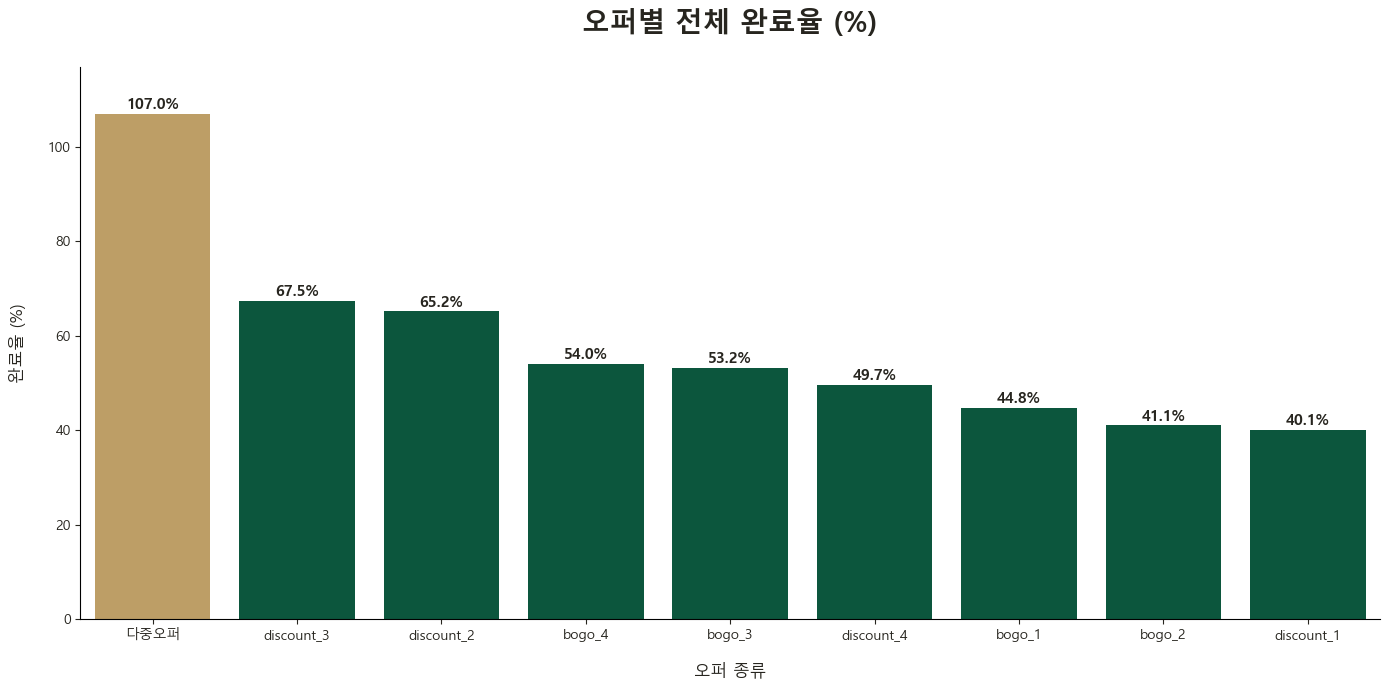

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 테마 컬러
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# 다중오퍼 골드 포인트
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in funnel_summary['final_label']]

ax = sns.barplot(data=funnel_summary, x='final_label', y='전체완료율', palette=colors)

plt.title('오퍼별 전체 완료율 (%)', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=15)

# 막대 위에 퍼센트 표시
for i, v in enumerate(funnel_summary['전체완료율']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.ylim(0, max(funnel_summary['전체완료율']) + 10) # 여유 공간 확보
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import ast

# 1. '다중오퍼' 결제 정보 미리 준비 (정합성 유지)
multi_txn_info = trans_df[trans_df['tx_offer_type'] == 'multi'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# 2. 다중오퍼로 끝난 경로(Key) 추출
completions_all = merge_df[merge_df['event'] == 'completed']
multi_path_keys = pd.merge(completions_all, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path_keys[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# 3. 발송(Received) 데이터 준비 및 카테고리 태깅 (informational 제외)
sent_df = merge_df[(merge_df['event'] == 'received') & 
                   (~merge_df['offer_label'].str.contains('informational', na=False))].copy()
sent_df = pd.merge(sent_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')
sent_df['final_label'] = sent_df.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

# 4. 카테고리별 총 발송수와 총 매출액 계산
sent_counts = sent_df.groupby('final_label').size().reset_index(name='총발송수')

# 매출 데이터 (9종 분류)
def get_offer_9_cat(row):
    if row['tx_offer_type'] == 'multi': return '다중오퍼'
    elif row['tx_offer_type'] in ['bogo', 'discount']:
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['tx_offer_type']
    return 'normal'

trans_df['offer_9_cat'] = trans_df.apply(get_offer_9_cat, axis=1)
offer_revenue = trans_df[trans_df['offer_9_cat'] != 'normal'].groupby('offer_9_cat')['amount'].sum().reset_index()
offer_revenue.columns = ['final_label', '총매출']

# 5. 최종 데이터 합치기 및 발송 1건당 평균 매출 계산
efficiency_df = pd.merge(sent_counts, offer_revenue, on='final_label', how='left')
efficiency_df['발송1건당_평균매출'] = efficiency_df['총매출'] / efficiency_df['총발송수']

# 보기 좋게 정렬 (bogo -> discount -> 다중오퍼)
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
efficiency_df['final_label'] = pd.Categorical(efficiency_df['final_label'], categories=order, ordered=True)
efficiency_df = efficiency_df.sort_values('final_label').reset_index(drop=True)

# 결과 확인
display(efficiency_df[['final_label', '총발송수', '총매출', '발송1건당_평균매출']])

,final_label,총발송수,총매출,발송1건당_평균매출
0,bogo_1,7322,77583.39,10.595929
1,bogo_2,7320,68650.76,9.378519
2,bogo_3,7260,64625.47,8.901580
3,bogo_4,7268,70338.90,9.677889
4,discount_1,7249,73810.25,10.182129
5,discount_2,7351,79665.13,10.837319
6,discount_3,7258,82265.18,11.334414
7,discount_4,7323,65247.52,8.909944
8,다중오퍼,2691,34437.08,12.797131


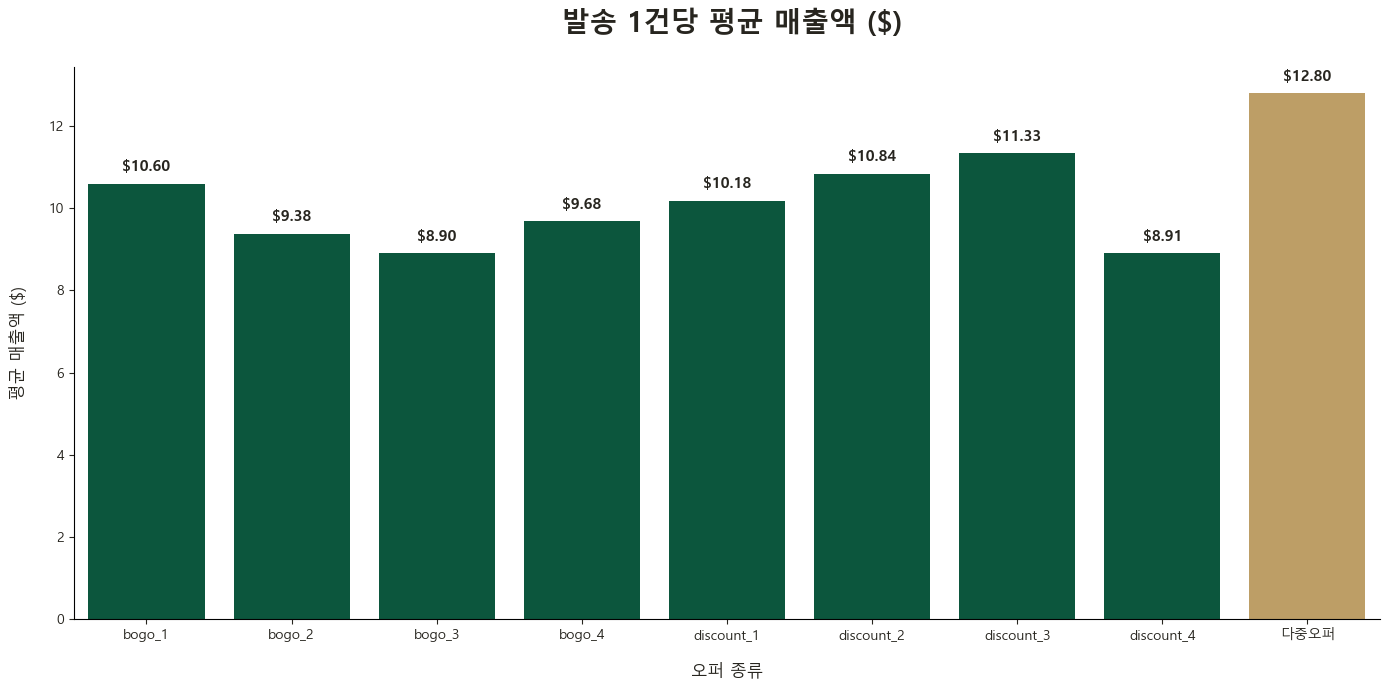

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# 다중오퍼 골드 포인트
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in efficiency_df['final_label']]

ax = sns.barplot(data=efficiency_df, x='final_label', y='발송1건당_평균매출', palette=colors)

plt.title(' 발송 1건당 평균 매출액 ($)', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('평균 매출액 ($)', fontsize=12, labelpad=15)

# 막대 위에 금액 표시 (소수점 둘째 자리까지)
for i, v in enumerate(efficiency_df['발송1건당_평균매출']):
    ax.text(i, v + 0.3, f"${v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import ast

# 1. 오퍼 관련 9개 항목만 필터링 (일반결제 제외)
def get_offer_9_cat(row):
    if row['tx_offer_type'] == 'multi': return '다중오퍼'
    elif row['tx_offer_type'] in ['bogo', 'discount']:
        # 문자열 리스트['bogo_1']에서 라벨 추출
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['tx_offer_type']
    return 'normal'

if 'offer_9_cat' not in trans_df.columns:
    trans_df['offer_9_cat'] = trans_df.apply(get_offer_9_cat, axis=1)

# 2. 오퍼별 총 매출액과 완료 건수(결제 횟수) 계산
completion_analysis = trans_df[trans_df['offer_9_cat'] != 'normal'].groupby('offer_9_cat').agg(
    총매출=('amount', 'sum'),
    완료건수=('amount', 'count')
).reset_index()

# 3. 완료 1건당 평균 매출액 계산
completion_analysis['완료1건당_평균매출'] = completion_analysis['총매출'] / completion_analysis['완료건수']

# 4. 보기 좋게 정렬 (bogo -> discount -> 다중오퍼)
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
completion_analysis['offer_9_cat'] = pd.Categorical(completion_analysis['offer_9_cat'], categories=order, ordered=True)
completion_analysis = completion_analysis.sort_values('offer_9_cat').reset_index(drop=True)

# 결과 확인
display(completion_analysis[['offer_9_cat', '완료건수', '총매출', '완료1건당_평균매출']])

,offer_9_cat,완료건수,총매출,완료1건당_평균매출
0,bogo_1,3283,77583.39,23.631858
1,bogo_2,2942,68650.76,23.334725
2,bogo_3,3715,64625.47,17.395820
3,bogo_4,3726,70338.90,18.877858
4,discount_1,2914,73810.25,25.329530
5,discount_2,4684,79665.13,17.007927
6,discount_3,4665,82265.18,17.634551
7,discount_4,3298,65247.52,19.783966
8,다중오퍼,1390,34437.08,24.774878


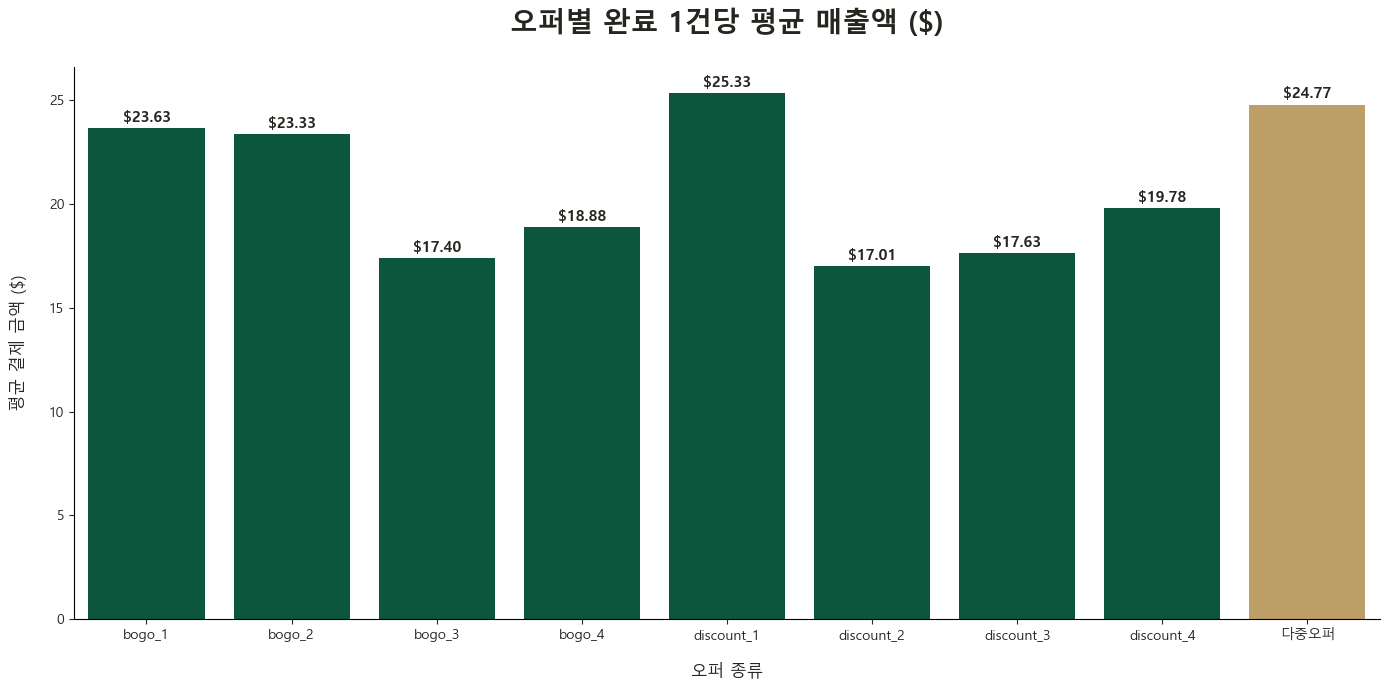

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타벅스 테마 컬러
SB_GREEN = '#006241'
SB_GOLD  = '#CBA258'
SB_BLACK = '#27251F'

plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(14, 7))

# 다중오퍼 골드 포인트
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in completion_analysis['offer_9_cat']]

ax = sns.barplot(data=completion_analysis, x='offer_9_cat', y='완료1건당_평균매출', palette=colors)

plt.title('오퍼별 완료 1건당 평균 매출액 ($)', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('평균 결제 금액 ($)', fontsize=12, labelpad=15)

# 막대 위에 금액 표시
for i, v in enumerate(completion_analysis['완료1건당_평균매출']):
    ax.text(i, v + 0.3, f"${v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

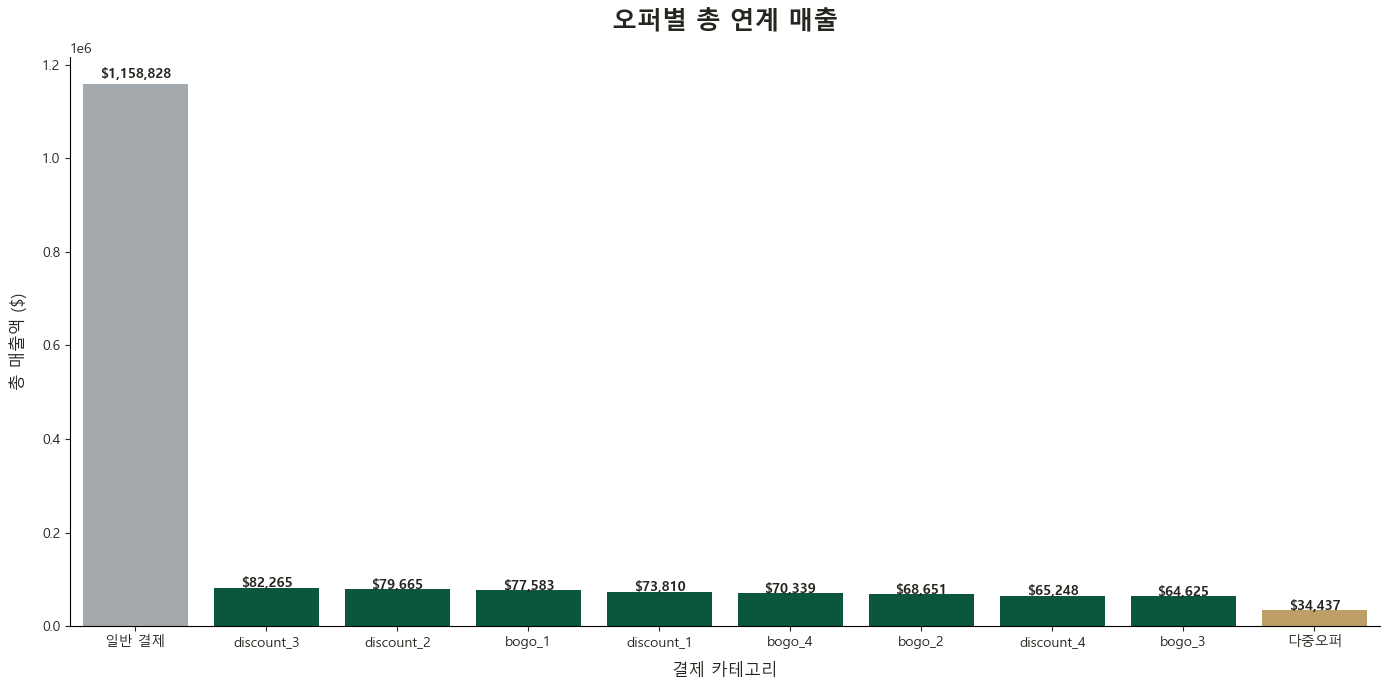

  final_category      amount
0          일반 결제  1158828.29
1     discount_3    82265.18
2     discount_2    79665.13
3         bogo_1    77583.39
4     discount_1    73810.25
5         bogo_4    70338.90
6         bogo_2    68650.76
7     discount_4    65247.52
8         bogo_3    64625.47
9           다중오퍼    34437.08


In [20]:
# 2. 카테고리명으로 데이터 정리
def get_final_label(row):
    if row['tx_offer_type'] == 'normal':
        return '일반 결제'
    elif row['tx_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼(bogo, discount)인 경우 리스트 안에 있는 라벨(예: bogo_4)을 꺼내옵니다.
        # 데이터가 문자열 형태의 리스트("['bogo_4']")이므로 ast.literal_eval을 사용합니다.
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['tx_offer_type']

trans_df['final_category'] = trans_df.apply(get_final_label, axis=1)

# 3. 카테고리별 총 매출액 계산
revenue_summary = trans_df.groupby('final_category')['amount'].sum().reset_index()
revenue_summary = revenue_summary.sort_values(by='amount', ascending=False).reset_index(drop=True)

# 4. 시각화 ( 스타벅스 테마)
SB_GREEN       = '#006241'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북은 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
})

plt.figure(figsize=(14, 7))

# 카테고리에 따른 색상 배정 함수
def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in revenue_summary['final_category']]

# 막대그래프 그리기
ax = sns.barplot(data=revenue_summary, x='final_category', y='amount', palette=colors)

plt.title('오퍼별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

# 막대 위에 금액 표시 (천 단위 콤마 추가)
for i, v in enumerate(revenue_summary['amount']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. 결과 데이터 출력
print(revenue_summary)

In [21]:
# 2. 카테고리 분류 로직 적용 (일반 결제 / 다중오퍼 / 개별 오퍼)
def get_final_label(row):
    if row['tx_offer_type'] == 'normal':
        return '일반 결제'
    elif row['tx_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼는 리스트에서 라벨 추출
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['tx_offer_type']

trans_df['final_category'] = trans_df.apply(get_final_label, axis=1)

# 3. 카테고리별 매출 합계 계산 
revenue_summary = trans_df.groupby('final_category')['amount'].sum().reset_index()

# 4. 합계 비교
sum_of_categories = revenue_summary['amount'].sum() # 표에 나온 항목들의 총합
actual_total_revenue = trans_df['amount'].sum()    # 원본 결제 데이터의 전체 총합

print(f"1. 카테고리별 매출 합계: ${sum_of_categories:,.2f}")
print(f"2. 실제 전체 매출 총합: ${actual_total_revenue:,.2f}")
print(f"3. 두 값의 차이: {sum_of_categories - actual_total_revenue}")

1. 카테고리별 매출 합계: $1,775,451.97
2. 실제 전체 매출 총합: $1,775,451.97
3. 두 값의 차이: 0.0


In [22]:
# 2. 4대 카테고리 매핑 (normal -> 일반 결제, multi -> 다중오퍼 등)
category_map = {
    'normal': '일반 결제',
    'discount': 'discount',
    'bogo': 'bogo',
    'multi': '다중오퍼'
}
trans_df['final_group'] = trans_df['tx_offer_type'].map(category_map)

# 3. 카테고리별 총 매출액 계산
revenue_summary = trans_df.groupby('final_group')['amount'].sum().reset_index()
revenue_summary.rename(columns={'amount': '총매출'}, inplace=True)

# 4. 출력 순서 고정 (일반 결제 -> discount -> bogo -> 다중오퍼)
order_list = ['일반 결제', 'discount', 'bogo', '다중오퍼']
revenue_summary['final_group'] = pd.Categorical(revenue_summary['final_group'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('final_group').reset_index(drop=True)

# 결과 확인
display(revenue_summary)

,final_group,총매출
0,일반 결제,1158828.29
1,discount,300988.08
2,bogo,281198.52
3,다중오퍼,34437.08


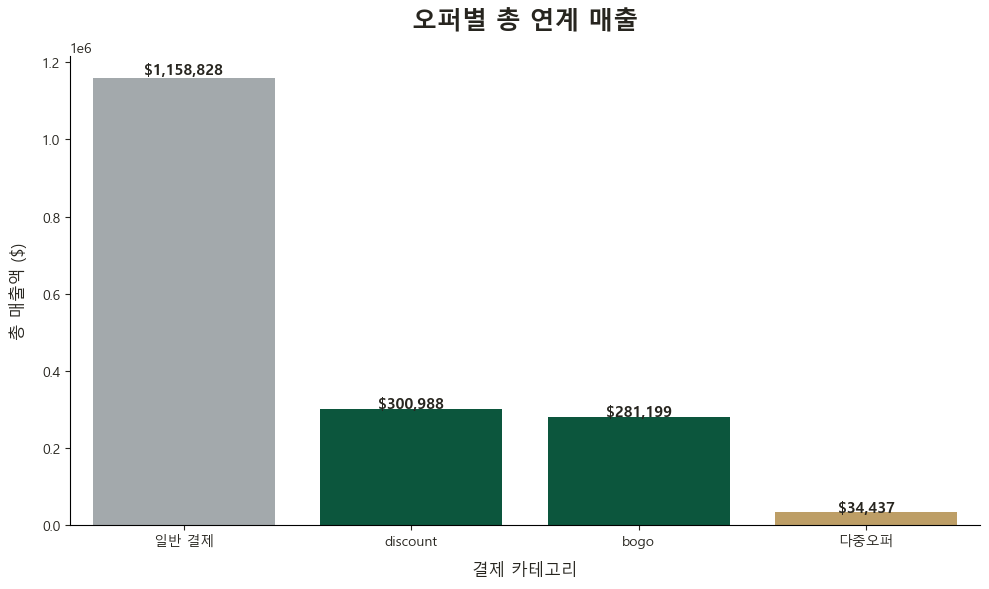

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#  스타벅스 컬러 설정 
SB_GREEN  = '#006241'
SB_GOLD   = '#CBA258'
SB_GREY   = '#A2AAAD'
SB_BLACK  = '#27251F'

# 한글 폰트 설정 (맥북은 'AppleGothic')
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(10, 6))

# 색상 팔레트 설정
colors = [SB_GREY, SB_GREEN, SB_GREEN, SB_GOLD]

# 막대그래프 그리기
ax = sns.barplot(data=revenue_summary, x='final_group', y='총매출', palette=colors)

plt.title('오퍼별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

# 막대 위에 금액 표시 (천 단위 콤마 추가)
for i, v in enumerate(revenue_summary['총매출']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

In [24]:
# 2. 10개 카테고리 정의 (일반 결제, 다중오퍼, 개별 오퍼 8개)
def get_detailed_label(row):
    if row['tx_offer_type'] == 'normal':
        return '일반 결제'
    elif row['tx_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼는 리스트 안의 라벨(예: bogo_1)을 직접 가져옵니다.
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['tx_offer_type']

trans_df['detailed_category'] = trans_df.apply(get_detailed_label, axis=1)

# 3. 평균 객단가 계산 (총매출 / 고유 고객 수)
analysis = trans_df.groupby('detailed_category').agg(
    총매출=('amount', 'sum'),
    고객수=('person', 'nunique')
).reset_index()

analysis['평균객단가'] = analysis['총매출'] / analysis['고객수']

# 4. 객단가 높은 순으로 내림차순 정렬
analysis = analysis.sort_values(by='평균객단가', ascending=False).reset_index(drop=True)

# 결과 확인
display(analysis)

,detailed_category,총매출,고객수,평균객단가
0,일반 결제,1158828.29,16156,71.727426
1,discount_1,73810.25,2623,28.139630
2,bogo_1,77583.39,2883,26.910645
3,bogo_2,68650.76,2590,26.506085
4,다중오퍼,34437.08,1360,25.321382
5,discount_4,65247.52,2935,22.230842
6,bogo_4,70338.90,3304,21.289013
7,discount_3,82265.18,4056,20.282342
8,bogo_3,64625.47,3301,19.577543
9,discount_2,79665.13,4083,19.511421


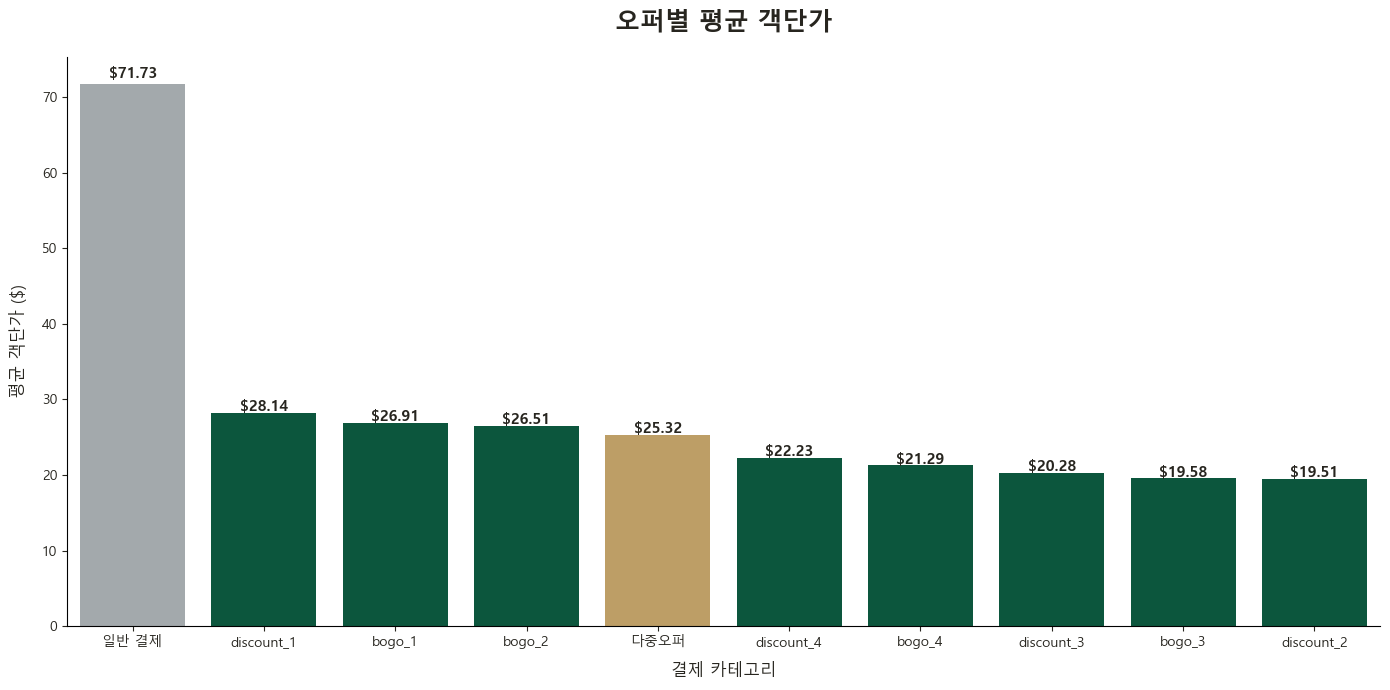

In [25]:

# 2. 10개 카테고리 세분화 (일반 결제, 다중오퍼, 개별 오퍼 8개)
def get_detailed_label(row):
    if row['tx_offer_type'] == 'normal':
        return '일반 결제'
    elif row['tx_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼는 리스트 형태의 문자열에서 실제 라벨을 꺼내옵니다.
        # 예: "['bogo_1']" -> 'bogo_1'
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['tx_offer_type']

trans_df['detailed_category'] = trans_df.apply(get_detailed_label, axis=1)

# 3. 평균 객단가 계산 (총매출 / 고유 고객 수)
analysis = trans_df.groupby('detailed_category').agg(
    총매출=('amount', 'sum'),
    고객수=('person', 'nunique')
).reset_index()

analysis['평균객단가'] = analysis['총매출'] / analysis['고객수']

# 보기 좋게 객단가 높은 순으로 정렬합니다.
analysis = analysis.sort_values(by='평균객단가', ascending=False).reset_index(drop=True)

# 4. 시각화 ( 스타벅스 테마 컬러)
SB_GREEN  = '#006241'
SB_GOLD   = '#CBA258'
SB_GREY   = '#A2AAAD'
SB_BLACK  = '#27251F'

# 한글 폰트 설정 (환경에 맞춰 'Malgun Gothic' 또는 'AppleGothic' 사용)
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
})

plt.figure(figsize=(14, 7))

# 카테고리별 색상 배정 (일반: 회색, 다중오퍼: 골드, 개별오퍼: 그린)
def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in analysis['detailed_category']]

# 막대그래프 그리기
ax = sns.barplot(data=analysis, x='detailed_category', y='평균객단가', palette=colors)

plt.title('오퍼별 평균 객단가', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('평균 객단가 ($)', fontsize=12, labelpad=10)

# 막대 위에 소수점 둘째 자리까지 금액 표시
for i, v in enumerate(analysis['평균객단가']):
    ax.text(i, v + (v * 0.01), f"${v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

